# CAPSTONE PROJECT
- **Nama Projek :** EcoScan
- **ID Tim :** CC26-PSU289

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Berapa persentase tiap kategori sampah serta proporsi reuse, reduce, dan recycle berdasarkan hasil klasifikasi EcoScan?
- **Pertanyaan 2:** Kategori sampah apa yang paling dominan dan berapa proporsinya, serta bagaimana potensi pemanfaatannya untuk mengurangi volume sampah secara signifikan?
- **Pertanyaan 3:** Seberapa besar persentase sampah yang dapat dimanfaatkan kembali dibandingkan dengan sampah residu, dan bagaimana hal ini menunjukkan potensi EcoScan dalam mendukung pengelolaan sampah berkelanjutan?

## Import Semua Packages/Library yang Digunakan

In [1]:
import os
import zipfile
import random
import shutil
import hashlib
import math
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
os.listdir("/content/drive/MyDrive/DATASET ECOSCAN")

['DATASET ECOSCAN.zip']

In [4]:
zip_path = "/content/drive/MyDrive/DATASET ECOSCAN/DATASET ECOSCAN.zip"
extract_path = "/content/ecoscan_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset berhasil diekstrak.")

Dataset berhasil diekstrak.


In [5]:
os.listdir(extract_path)

['Kertas', 'Plastik', 'Kaca', 'Organik', 'Kardus', 'Residu', 'Logam']

In [6]:
dataset_path = Path("/content/ecoscan_dataset")
os.listdir(dataset_path)

['Kertas', 'Plastik', 'Kaca', 'Organik', 'Kardus', 'Residu', 'Logam']

## Data Wrangling

### Gathering Data

#### Load df ...

In [7]:
data = []

classes = [folder for folder in os.listdir(dataset_path) if (dataset_path / folder).is_dir()]

for cls in classes:
    folder = dataset_path / cls

    for file in folder.iterdir():
        if file.is_file():
            data.append({
                "class": cls,
                "file_path": str(file)
            })

df = pd.DataFrame(data)

print("Total data awal:", len(df))
df.head()

Total data awal: 18994


,class,file_path
0,Kertas,/content/ecoscan_dataset/Kertas/R_4853.jpg
1,Kertas,/content/ecoscan_dataset/Kertas/R_4709.jpg
2,Kertas,/content/ecoscan_dataset/Kertas/R_3101.jpg
3,Kertas,/content/ecoscan_dataset/Kertas/R_3116.jpg
4,Kertas,/content/ecoscan_dataset/Kertas/(87).jpg


In [8]:
df.tail()

,class,file_path
18989,Logam,/content/ecoscan_dataset/Logam/(41).jpg
18990,Logam,/content/ecoscan_dataset/Logam/R_8767.jpg
18991,Logam,/content/ecoscan_dataset/Logam/Metal_37.jpg
18992,Logam,/content/ecoscan_dataset/Logam/Metal_772.jpg
18993,Logam,/content/ecoscan_dataset/Logam/Metal_634.jpg


**Insight:**

Dataset berhasil dimuat ke dalam dataframe. Setiap baris merepresentasikan satu gambar, dengan kolom class sebagai kategori sampah dan file_path sebagai lokasi file gambar.

### Assessing Data

#### Identifying ... problem

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18994 entries, 0 to 18993
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   class      18994 non-null  object
 1   file_path  18994 non-null  object
dtypes: object(2)
memory usage: 296.9+ KB


In [10]:
df["class"].value_counts()

,count
class,
Organik,3569
Logam,3182
Plastik,3154
Residu,2930
Kertas,2901
Kaca,2173
Kardus,1085


In [11]:
df.isnull().sum()

,0
class,0
file_path,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe(include="all")

,class,file_path
count,18994,18994
unique,7,18994
top,Organik,/content/ecoscan_dataset/Logam/Metal_634.jpg
freq,3569,1


**Insight:**

Tahap assessing menunjukkan struktur dataset, jumlah data pada setiap kategori, missing value, dan duplikasi berbasis baris. Karena dataset berupa gambar, fokus utama assessment bukan pada nilai numerik, melainkan pada validitas file, distribusi kelas, dan kualitas data gambar.

Hasil Pengamatan:
Dataset tidak memiliki missing value pada kolom utama.
Jumlah data tiap kelas dapat dilihat dari distribusi class.
Duplikasi berdasarkan baris belum cukup untuk mendeteksi gambar yang sama, sehingga perlu pengecekan duplikat berdasarkan isi file.

### Cleaning Data

#### Fixing ... problem

In [14]:
corrupt_files = []

for _, row in df.iterrows():
    try:
        img = Image.open(row["file_path"])
        img.verify()
    except:
        corrupt_files.append(row["file_path"])

print("Jumlah file rusak:", len(corrupt_files))

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Jumlah file rusak: 0


In [15]:
for file in corrupt_files:
    if os.path.exists(file):
        os.remove(file)

df = df[~df["file_path"].isin(corrupt_files)]

print("Total data setelah menghapus file rusak:", len(df))

Total data setelah menghapus file rusak: 18994


In [16]:
def get_file_hash(file_path):
    with open(file_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

seen_hashes = {}
duplicate_files = []

for _, row in df.iterrows():
    file_path = row["file_path"]
    file_hash = get_file_hash(file_path)

    if file_hash in seen_hashes:
        duplicate_files.append(file_path)
    else:
        seen_hashes[file_hash] = file_path

print("Jumlah file duplikat:", len(duplicate_files))

Jumlah file duplikat: 303


In [17]:
for file in duplicate_files:
    if os.path.exists(file):
        os.remove(file)

df = df[~df["file_path"].isin(duplicate_files)]

print("Total data setelah menghapus duplikat:", len(df))

Total data setelah menghapus duplikat: 18691


In [18]:
small_images = []

for _, row in df.iterrows():
    try:
        img = Image.open(row["file_path"])
        width, height = img.size

        if width < 50 or height < 50:
            small_images.append(row["file_path"])
    except:
        pass

print("Jumlah gambar terlalu kecil:", len(small_images))

Jumlah gambar terlalu kecil: 24


In [19]:
for file in small_images:
    if os.path.exists(file):
        os.remove(file)

df = df[~df["file_path"].isin(small_images)]

print("Total data setelah menghapus gambar terlalu kecil:", len(df))

Total data setelah menghapus gambar terlalu kecil: 18667


In [20]:
cleaning_summary = pd.DataFrame({
    "Keterangan": [
        "Total data awal",
        "File rusak dihapus",
        "File duplikat dihapus",
        "Gambar terlalu kecil dihapus",
        "Total data akhir"
    ],
    "Jumlah": [
        len(data),
        len(corrupt_files),
        len(duplicate_files),
        len(small_images),
        len(df)
    ]
})

cleaning_summary

,Keterangan,Jumlah
0,Total data awal,18994
1,File rusak dihapus,0
2,File duplikat dihapus,303
3,Gambar terlalu kecil dihapus,24
4,Total data akhir,18667


In [21]:
import shutil

shutil.make_archive(
    "/content/drive/MyDrive/ecoscan_clean",
    'zip',
    "/content/ecoscan_dataset"
)

'/content/drive/MyDrive/ecoscan_clean.zip'

In [46]:
import shutil

shutil.make_archive(
    "/content/drive/MyDrive/ecoscan_split",
    'zip',
    "/content/ecoscan_split"
)

'/content/drive/MyDrive/ecoscan_split.zip'

**Insight:**

- Tahap cleaning data dilakukan untuk memastikan bahwa dataset yang digunakan memiliki kualitas yang baik dan siap untuk dianalisis lebih lanjut.

- Berdasarkan proses yang telah dilakukan, tidak ditemukan missing value pada dataset, sehingga seluruh data memiliki informasi kategori dan file path yang lengkap. Selain itu, tidak ditemukan duplikasi data berbasis baris, namun pengecekan tetap dilakukan untuk memastikan tidak ada file gambar yang sama dengan nama berbeda.

- Selanjutnya, dilakukan pengecekan terhadap file gambar yang rusak, yaitu gambar yang tidak dapat dibuka atau diverifikasi. File yang terdeteksi rusak dihapus dari dataset agar tidak menyebabkan error pada proses analisis maupun pemodelan.

- Selain itu, dilakukan juga pengecekan terhadap ukuran gambar, di mana gambar yang terlalu kecil dihapus karena berpotensi tidak memiliki informasi visual yang cukup untuk proses klasifikasi.

- Setelah seluruh proses cleaning dilakukan, dataset menjadi lebih bersih dan konsisten, sehingga dapat digunakan untuk analisis lebih lanjut dengan tingkat keandalan yang lebih tinggi.

## Exploratory Data Analysis (EDA)

### Explore ...

### Pertanyaan 1 : Berapa persentase tiap kategori sampah serta proporsi reuse, reduce, dan recycle berdasarkan hasil klasifikasi EcoScan?

In [23]:
df["class"].value_counts()

,count
class,
Organik,3557
Logam,3169
Plastik,3152
Kertas,2901
Residu,2632
Kaca,2171
Kardus,1085


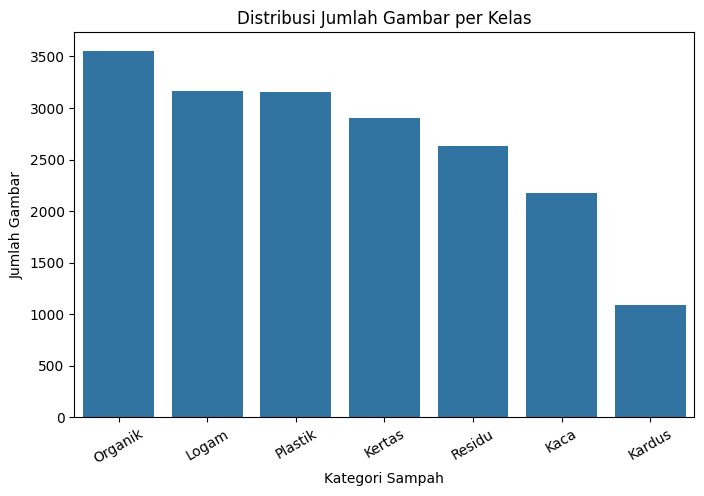

In [24]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="class", order=df["class"].value_counts().index)
plt.title("Distribusi Jumlah Gambar per Kelas")
plt.xlabel("Kategori Sampah")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=30)
plt.show()

### Pertanyaan 2 : Kategori sampah apa yang paling dominan dan berapa proporsinya, serta bagaimana potensi pemanfaatannya untuk mengurangi volume sampah secara signifikan

In [25]:
class_distribution = df["class"].value_counts().reset_index()
class_distribution.columns = ["class", "count"]
class_distribution["percentage"] = (
    class_distribution["count"] / class_distribution["count"].sum()
) * 100

class_distribution

,class,count,percentage
0,Organik,3557,19.055017
1,Logam,3169,16.976483
2,Plastik,3152,16.885413
3,Kertas,2901,15.540794
4,Residu,2632,14.099748
5,Kaca,2171,11.630149
6,Kardus,1085,5.812396


### Pertanyaan 3 : Seberapa besar persentase sampah yang dapat dimanfaatkan kembali dibandingkan dengan sampah residu, dan bagaimana hal ini menunjukkan potensi EcoScan dalam mendukung pengelolaan sampah berkelanjutan?

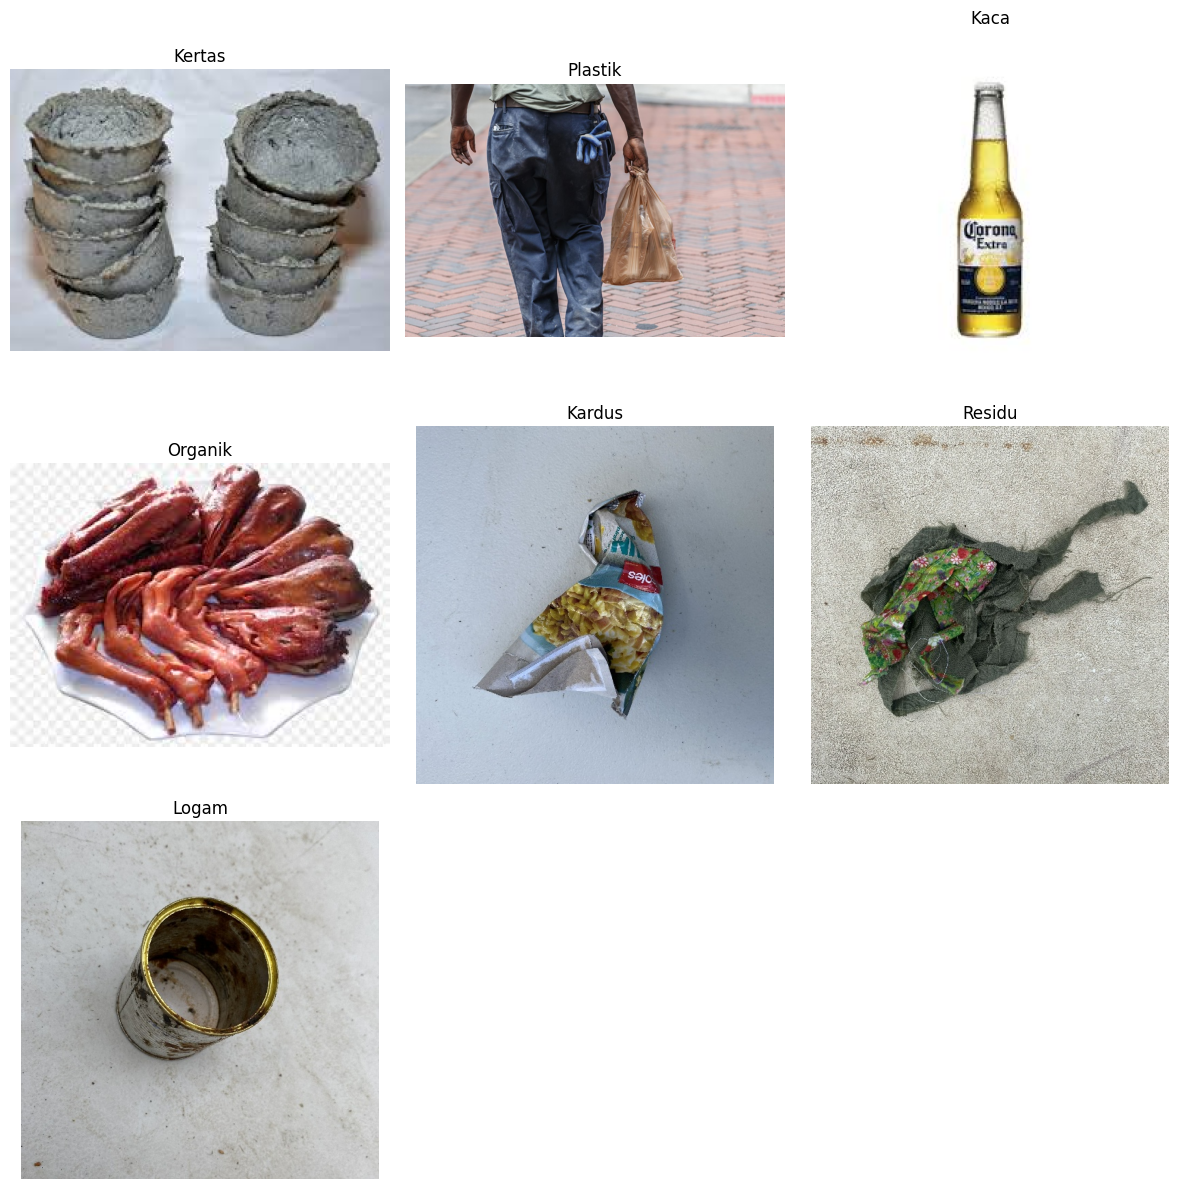

In [26]:
cols = 3
rows = math.ceil(len(classes) / cols)

plt.figure(figsize=(12, 4 * rows))

for i, cls in enumerate(classes):
    sample = df[df["class"] == cls].sample(1).iloc[0]
    img = Image.open(sample["file_path"])

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

**Insight:**
- Distribusi kategori menunjukkan jumlah gambar pada tiap kelas sampah. Jika terdapat kategori yang sangat dominan, model berpotensi lebih sering mengenali kategori tersebut dibanding kategori lain. Hasil ini menjadi dasar untuk menjawab Pertanyaan 1 terkait persentase tiap kategori sampah.
- Persentase tiap kategori digunakan untuk mengetahui kontribusi masing-masing jenis sampah terhadap total dataset. Hasil ini secara langsung menjawab Pertanyaan 1, yaitu mengenai persentase tiap kategori sampah berdasarkan hasil klasifikasi EcoScan.
- Visualisasi sampel gambar membantu memastikan bahwa gambar dalam setiap kategori sesuai dengan labelnya. Pemeriksaan visual ini penting karena kesalahan label dapat membuat model belajar pola yang salah.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Berapa persentase tiap kategori sampah serta proporsi reuse, reduce, dan recycle berdasarkan hasil klasifikasi EcoScan?

In [27]:
three_r_mapping = {
    "Kaca": "Reuse",
    "Kertas": "Recycle",
    "Logam": "Recycle",
    "Kardus": "Recycle",
    "Organik": "Recycle",
    "Plastik": "Recycle",
    "Others": "Reduce",
    "Residu": "Reduce"
}

df["3R"] = df["class"].map(three_r_mapping)

df.head()

,class,file_path,3R
0,Kertas,/content/ecoscan_dataset/Kertas/R_4853.jpg,Recycle
1,Kertas,/content/ecoscan_dataset/Kertas/R_4709.jpg,Recycle
2,Kertas,/content/ecoscan_dataset/Kertas/R_3101.jpg,Recycle
3,Kertas,/content/ecoscan_dataset/Kertas/R_3116.jpg,Recycle
4,Kertas,/content/ecoscan_dataset/Kertas/(87).jpg,Recycle


In [28]:
df[df["3R"].isnull()]["class"].unique()

array([], dtype=object)

In [29]:
three_r_distribution = df["3R"].value_counts().reset_index()
three_r_distribution.columns = ["3R", "count"]
three_r_distribution["percentage"] = (
    three_r_distribution["count"] / three_r_distribution["count"].sum()
) * 100

three_r_distribution

,3R,count,percentage
0,Recycle,13864,74.270102
1,Reduce,2632,14.099748
2,Reuse,2171,11.630149


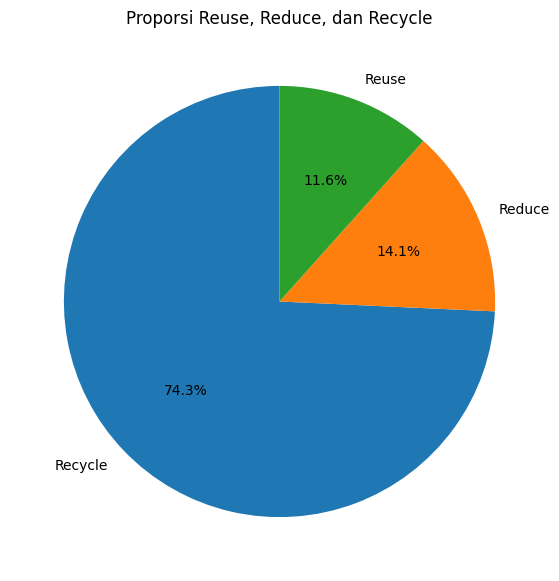

In [30]:
plt.figure(figsize=(7, 7))
plt.pie(
    three_r_distribution["count"],
    labels=three_r_distribution["3R"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Proporsi Reuse, Reduce, dan Recycle")
plt.show()

**Insight:**

Berdasarkan hasil analisis, proporsi pengelolaan sampah berdasarkan konsep 3R menunjukkan bahwa:
- Recycle sebesar 74.3% (13.864 data)
- Reduce sebesar 14.1% (2.632 data)
- Reuse sebesar 11.6% (2.171 data)

Hasil ini menunjukkan bahwa sekitar 85,9% sampah dalam dataset EcoScan masih memiliki potensi untuk dimanfaatkan kembali melalui proses reuse dan recycle. Sementara itu, sekitar 14,1% sampah termasuk dalam kategori reduce, yang menunjukkan adanya sebagian sampah yang perlu diminimalkan penggunaannya atau memiliki keterbatasan dalam proses pemanfaatan kembali.

Dominasi kategori recycle mengindikasikan bahwa sebagian besar sampah yang teridentifikasi, seperti plastik, kertas, logam, kardus, dan organik, memiliki peluang yang besar untuk diolah kembali menjadi produk yang bernilai guna. Kondisi ini menunjukkan bahwa mayoritas sampah dalam dataset tidak berakhir sebagai limbah residu, melainkan masih dapat dimanfaatkan dalam sistem ekonomi sirkular.

Dengan demikian, hasil analisis ini menjawab Pertanyaan 1 dengan menunjukkan bahwa sebagian besar sampah yang diklasifikasikan oleh EcoScan memiliki potensi pengelolaan yang berkelanjutan melalui penerapan konsep 3R, khususnya pada aspek recycle yang menjadi kategori paling dominan.

### Pertanyaan 2 : Kategori sampah apa yang paling dominan dan berapa proporsinya, serta bagaimana potensi pemanfaatannya untuk mengurangi volume sampah secara signifikan?

In [31]:
dominant_category = class_distribution.sort_values(
    by="count", ascending=False
).iloc[0]

dominant_category

,0
class,Organik
count,3557
percentage,19.055017


In [33]:
print(
    f"Kategori sampah paling dominan adalah {dominant_category['class']} "
    f"dengan jumlah {dominant_category['count']} data "
    f"atau sekitar {dominant_category['percentage']:.2f}% dari total dataset."
)

Kategori sampah paling dominan adalah Organik dengan jumlah 3557 data atau sekitar 19.06% dari total dataset.


In [34]:
dominant_class = dominant_category["class"]
dominant_3r = three_r_mapping.get(dominant_class, "Belum diketahui")

print(f"Kategori dominan: {dominant_class}")
print(f"Potensi pengelolaan 3R: {dominant_3r}")

Kategori dominan: Organik
Potensi pengelolaan 3R: Recycle


**Insight:**

Berdasarkan hasil analisis, kategori sampah yang paling dominan adalah Organik dengan jumlah 3.557 data atau sekitar 19,06% dari total dataset.

Kategori organik termasuk dalam kategori Recycle, yang berarti memiliki potensi tinggi untuk dimanfaatkan kembali melalui berbagai metode pengolahan, seperti komposting dan pengolahan limbah organik menjadi pupuk. Hal ini menunjukkan bahwa sebagian besar sampah organik tidak harus berakhir sebagai limbah residu, tetapi masih dapat diolah menjadi produk yang memiliki nilai guna dan manfaat bagi lingkungan.

Dominasi kategori organik mengindikasikan bahwa sampah rumah tangga dan aktivitas sehari-hari masih menjadi penyumbang utama dalam komposisi sampah yang teridentifikasi oleh EcoScan. Oleh karena itu, pengelolaan sampah organik dapat menjadi fokus utama dalam upaya pengurangan volume sampah yang dikirim ke tempat pembuangan akhir (TPA).

Jika dikelola secara optimal, pemanfaatan sampah organik melalui proses daur ulang biologis dapat membantu mengurangi pencemaran lingkungan, meningkatkan pemanfaatan sumber daya, serta mendukung penerapan ekonomi sirkular yang berkelanjutan.

Dengan demikian, analisis ini menjawab Pertanyaan 2 dengan menunjukkan bahwa kategori Organik merupakan kategori yang paling dominan dalam dataset EcoScan sekaligus memiliki potensi terbesar untuk dimanfaatkan kembali, sehingga dapat berkontribusi secara signifikan dalam upaya pengurangan volume sampah dan pengelolaan sampah yang berkelanjutan.


### Pertanyaan 3 : Seberapa besar persentase sampah yang dapat dimanfaatkan kembali dibandingkan dengan sampah residu, dan bagaimana hal ini menunjukkan potensi EcoScan dalam mendukung pengelolaan sampah berkelanjutan?

In [35]:
df["status_pengelolaan"] = df["3R"].apply(
    lambda x: "Dapat dimanfaatkan kembali" if x in ["Reuse", "Recycle"] else "Residu"
)

status_distribution = df["status_pengelolaan"].value_counts().reset_index()
status_distribution.columns = ["status", "count"]
status_distribution["percentage"] = (
    status_distribution["count"] / status_distribution["count"].sum()
) * 100

status_distribution

,status,count,percentage
0,Dapat dimanfaatkan kembali,16035,85.900252
1,Residu,2632,14.099748


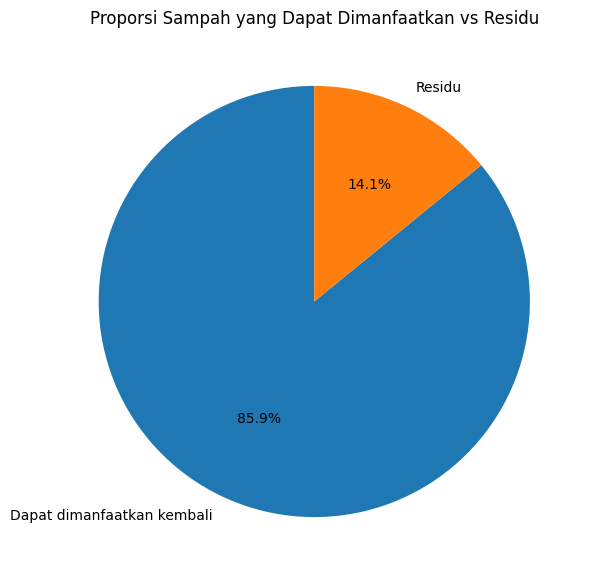

In [36]:
plt.figure(figsize=(7, 7))
plt.pie(
    status_distribution["count"],
    labels=status_distribution["status"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Proporsi Sampah yang Dapat Dimanfaatkan vs Residu")
plt.show()

**Insight:**

Berdasarkan hasil analisis, proporsi sampah menunjukkan bahwa:

- Sampah yang dapat dimanfaatkan kembali sebesar 85,90% (16.035 data)
- Sampah residu sebesar 14.10% (2.632 data)

Hasil ini menunjukkan bahwa sebagian besar sampah yang teridentifikasi oleh EcoScan masih memiliki nilai guna dan berpotensi untuk dikelola kembali melalui proses reuse maupun recycle. Tingginya persentase sampah yang dapat dimanfaatkan kembali menunjukkan peluang yang besar dalam penerapan pengelolaan sampah berkelanjutan dan pengurangan volume sampah yang berakhir di tempat pembuangan akhir (TPA).

Di sisi lain, proporsi sampah residu yang hanya sebesar 14,10% mengindikasikan bahwa hanya sebagian kecil sampah yang memiliki keterbatasan untuk dimanfaatkan kembali. Kondisi ini menjadi indikator positif bahwa mayoritas sampah masih dapat diarahkan ke proses pengolahan yang lebih produktif dan ramah lingkungan.

Dengan demikian, analisis ini menjawab Pertanyaan 3 dengan menunjukkan bahwa EcoScan memiliki potensi yang kuat dalam mendukung pengelolaan sampah berkelanjutan. Melalui kemampuan klasifikasi yang dimiliki, EcoScan dapat membantu mengidentifikasi sampah yang masih bernilai guna sehingga pemanfaatan kembali dapat ditingkatkan dan jumlah sampah residu dapat diminimalkan.

## Data Preparation

In [37]:
split_path = Path("/content/ecoscan_split")

train_ratio = 0.7
val_ratio = 0.15

for cls in classes:
    class_df = df[df["class"] == cls]
    image_paths = list(class_df["file_path"])

    random.shuffle(image_paths)

    train_end = int(len(image_paths) * train_ratio)
    val_end = train_end + int(len(image_paths) * val_ratio)

    split_data = {
        "train": image_paths[:train_end],
        "validation": image_paths[train_end:val_end],
        "test": image_paths[val_end:]
    }

    for split_name, files in split_data.items():
        split_folder = split_path / split_name / cls
        split_folder.mkdir(parents=True, exist_ok=True)

        for file_path in files:
            src = Path(file_path)
            dst = split_folder / src.name
            shutil.copy(src, dst)

print("Dataset berhasil dibagi menjadi train, validation, dan test.")

Dataset berhasil dibagi menjadi train, validation, dan test.


In [38]:
split_summary = []

for split_name in ["train", "validation", "test"]:
    for cls in classes:
        folder = split_path / split_name / cls
        count = len(list(folder.iterdir()))

        split_summary.append({
            "split": split_name,
            "class": cls,
            "count": count
        })

df_split = pd.DataFrame(split_summary)
df_split

,split,class,count
0,train,Kertas,2030
1,train,Plastik,2206
2,train,Kaca,1519
3,train,Organik,2489
4,train,Kardus,759
5,train,Residu,1842
6,train,Logam,2218
7,validation,Kertas,435
8,validation,Plastik,472
9,validation,Kaca,325


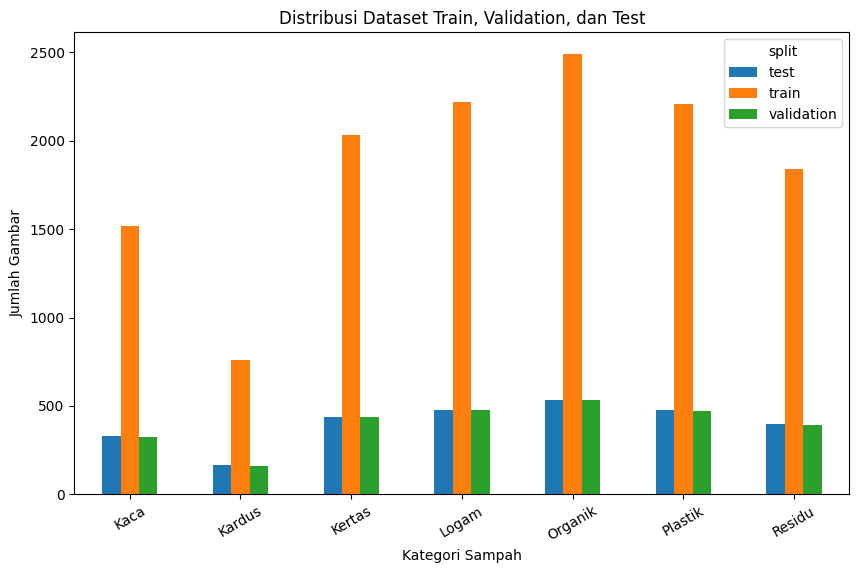

In [39]:
pivot_split = df_split.pivot(
    index="class",
    columns="split",
    values="count"
)

pivot_split.plot(kind="bar", figsize=(10, 6))
plt.title("Distribusi Dataset Train, Validation, dan Test")
plt.xlabel("Kategori Sampah")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=30)
plt.show()

**Insight:**

Visualisasi hasil split menunjukkan pembagian jumlah data pada train, validation, dan test untuk setiap kelas. Jika pembagian cukup seimbang, maka dataset siap digunakan untuk proses modeling.

## Conclusion & Recommendation

In [40]:
print("Jumlah kelas:", df["class"].nunique())
print("Total data awal:", len(data))
print("Total data akhir setelah cleaning:", len(df))
print("File rusak dihapus:", len(corrupt_files))
print("File duplikat dihapus:", len(duplicate_files))
print("Gambar terlalu kecil dihapus:", len(small_images))

df["class"].value_counts()

Jumlah kelas: 7
Total data awal: 18994
Total data akhir setelah cleaning: 18667
File rusak dihapus: 0
File duplikat dihapus: 303
Gambar terlalu kecil dihapus: 24


,count
class,
Organik,3557
Logam,3169
Plastik,3152
Kertas,2901
Residu,2632
Kaca,2171
Kardus,1085


Berdasarkan hasil analisis, dataset EcoScan telah melalui proses gathering, assessing, cleaning, EDA, visualisasi, mapping 3R, dan data preparation.

Pada tahap cleaning, dataset berhasil dibersihkan dari 303 file duplikat dan 24 gambar berukuran terlalu kecil, sehingga total data berkurang dari 18.994 menjadi 18.667 data. Hal ini memastikan bahwa dataset yang digunakan memiliki kualitas yang lebih baik dan minim noise.

Hasil analisis menunjukkan bahwa:

- Sebesar 74,3% sampah termasuk kategori Recycle, 11,6% termasuk kategori Reuse, dan 14,1% termasuk kategori Reduce. Hal ini menunjukkan bahwa sekitar 85,9% sampah memiliki potensi untuk dimanfaatkan kembali melalui penerapan konsep 3R.
- Kategori sampah yang paling dominan adalah Organik dengan jumlah 3.557 data atau sekitar 19,06% dari total dataset. Kategori ini memiliki potensi tinggi untuk diolah kembali, misalnya melalui proses komposting, sehingga dapat menjadi fokus utama dalam strategi pengurangan volume sampah.
- Sebanyak 16.035 data (85,90%) termasuk kategori sampah yang dapat dimanfaatkan kembali, sedangkan 2.632 data (14,10%) termasuk kategori residu. Hasil ini menunjukkan bahwa mayoritas sampah masih memiliki nilai guna dan berpotensi untuk diolah kembali.

Dengan demikian, EcoScan tidak hanya berfungsi sebagai sistem klasifikasi sampah, tetapi juga dapat menjadi alat pendukung pengambilan keputusan dalam pengelolaan sampah berbasis data. Sistem ini menunjukkan potensi yang kuat dalam mendukung pengelolaan sampah berkelanjutan dengan memaksimalkan pemanfaatan kembali dan meminimalkan limbah residu.

## Dashboard

In [41]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 42.2 MB/s eta 0:00:00


In [42]:
%%writefile dashboard.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="EcoScan Dashboard",
    page_icon="♻️",
    layout="wide"
)



st.markdown("""
<style>
.stApp {
    background: linear-gradient(135deg, #f4fbf6 0%, #eaf7ee 100%);
}

section[data-testid="stSidebar"] {
    background-color: #f7faf8;
}

.hero {
    background: linear-gradient(90deg, #1b5e20, #43a047);
    padding: 28px;
    border-radius: 22px;
    color: white;
    margin-bottom: 28px;
    box-shadow: 0 8px 24px rgba(0,0,0,0.12);
}

.hero h1 {
    font-size: 42px;
    margin-bottom: 6px;
}

.hero p {
    font-size: 17px;
    margin: 0;
    opacity: 0.95;
}

.metric-card {
    background: white;
    padding: 18px;
    border-radius: 18px;
    box-shadow: 0 5px 16px rgba(0,0,0,0.08);
    text-align: center;
    min-height: 115px;
}

.metric-title {
    color: #5f7d64;
    font-size: 14px;
    margin-bottom: 8px;
}

.metric-value {
    color: #1b5e20;
    font-size: 28px;
    font-weight: 800;
}

.metric-note {
    color: #78909c;
    font-size: 13px;
    margin-top: 4px;
}

.chart-card {
    background: white;
    padding: 20px;
    border-radius: 18px;
    box-shadow: 0 5px 16px rgba(0,0,0,0.08);
    margin-bottom: 20px;
}

.insight-box {
    background-color: #e8f5e9;
    border-left: 6px solid #2e7d32;
    padding: 18px 20px;
    border-radius: 14px;
    color: #1b5e20;
    font-size: 15px;
    line-height: 1.7;
    margin-top: 18px;
}

.small-caption {
    color: #6b7c6f;
    font-size: 14px;
}
</style>
""", unsafe_allow_html=True)



class_data = pd.DataFrame({
    "Kategori": ["Organik", "Plastik", "Kertas", "Kaca", "Logam", "Others", "Residu"],
    "Jumlah": [3557, 3169, 3152, 2901, 2632, 2171, 1085],
})


class_data["Persentase"] = (class_data["Jumlah"] / class_data["Jumlah"].sum() * 100).round(2).astype(str) + "%"

three_r_data = pd.DataFrame({
    "3R": ["Recycle", "Reuse", "Reduce"],
    "Jumlah": [13864, 2171, 2632],
    "Persentase": [74.30, 11.60, 14.10]
})

status_data = pd.DataFrame({
    "Status": ["Dapat Dimanfaatkan", "Residu"],
    "Jumlah": [16035, 2632],
    "Persentase": [85.90, 14.10]
})

status_data["Persentase"] = status_data["Persentase"].astype(str) + "%"


def metric_card(title, value, note=""):
    st.markdown(
        f"""
        <div class="metric-card">
            <div class="metric-title">{title}</div>
            <div class="metric-value">{value}</div>
            <div class="metric-note">{note}</div>
        </div>
        """,
        unsafe_allow_html=True
    )


def insight(text):
    st.markdown(
        f"""
        <div class="insight-box">
            {text}
        </div>
        """,
        unsafe_allow_html=True
    )

def bar_chart(data, title):
    fig, ax = plt.subplots(figsize=(6.6, 3.4))
    colors = ["#2E7D32", "#43A047", "#66BB6A", "#81C784", "#A5D6A7", "#C8E6C9", "#9E9E9E"]

    ax.bar(data["Kategori"], data["Jumlah"], color=colors[:len(data)])
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Kategori", fontsize=10)
    ax.set_ylabel("Jumlah", fontsize=10)
    ax.tick_params(axis="x", labelrotation=25, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    st.pyplot(fig, use_container_width=False)

def pie_chart(data, label_col, value_col, title):
    fig, ax = plt.subplots(figsize=(4.4, 4.4))
    colors = ["#2E7D32", "#81C784", "#F9A825"]

    ax.pie(
        data[value_col],
        labels=data[label_col],
        autopct="%1.1f%%",
        startangle=90,
        colors=colors[:len(data)],
        textprops={"fontsize": 9}
    )
    ax.set_title(title, fontsize=12, fontweight="bold")

    plt.tight_layout()
    st.pyplot(fig, use_container_width=False)



st.sidebar.title("♻️ EcoScan")
st.sidebar.caption("Waste Insight Dashboard")

menu = st.sidebar.radio(
    "Pilih Analisis",
    [
        "Overview",
        "Pertanyaan 1: Distribusi & 3R",
        "Pertanyaan 2: Kategori Dominan",
        "Pertanyaan 3: Sustainability"
    ]
)



st.markdown("""
<div class="hero">
    <h1>♻️ EcoScan Dashboard</h1>
    <p>Analisis kategori sampah, potensi 3R, dan dampak sustainability berdasarkan dataset EcoScan.</p>
</div>
""", unsafe_allow_html=True)



if menu == "Overview":
    st.header("🌱 Ringkasan Utama")

    c1, c2, c3, c4 = st.columns(4)
    with c1:
        metric_card("Total Data", "18.667", "Gambar")
    with c2:
        metric_card("Kategori Dominan", "Organik", "19.06%")
    with c3:
        metric_card("Dapat Dimanfaatkan", "85.90%", "Reuse/Recycle")
    with c4:
        metric_card("Residu", "14.10%", "Sulit Diolah")

    st.write("")
    col1, col2 = st.columns([1.15, 0.85])

    with col1:
        st.markdown('<div class="chart-card">', unsafe_allow_html=True)
        st.subheader("📊 Distribusi Kategori Sampah")
        bar_chart(class_data, "Jumlah Data per Kategori")
        st.markdown("</div>", unsafe_allow_html=True)

    with col2:
        st.markdown('<div class="chart-card">', unsafe_allow_html=True)
        st.subheader("📋 Ringkasan Data")
        st.dataframe(
            class_data[["Kategori", "Jumlah", "Persentase"]],
            hide_index=True,
            use_container_width=True
        )
        st.markdown("</div>", unsafe_allow_html=True)

    insight(
        "Mayoritas sampah dalam dataset EcoScan masih memiliki potensi untuk dimanfaatkan kembali. "
        "Hal ini menunjukkan bahwa EcoScan dapat membantu proses identifikasi sampah dan mendukung "
        "pengelolaan sampah berbasis data."
    )



elif menu == "Pertanyaan 1: Distribusi & 3R":
    st.write("Berapa persentase tiap kategori sampah serta proporsi reuse, reduce, dan recycle berdasarkan hasil klasifikasi EcoScan?")

    c1, c2, c3 = st.columns(3)
    with c1:
        metric_card("♻️ Recycle", "74.30%", "13.864 Data")
    with c2:
        metric_card("🔁 Reuse", "11.60%", "2.171 Data")
    with c3:
        metric_card("⚠️ Reduce", "14.10%", "2.632 Data")

    st.write("")
    col1, col2 = st.columns(2)

    with col1:
        st.markdown('<div class="chart-card">', unsafe_allow_html=True)
        st.subheader("📊 Distribusi Kategori")
        bar_chart(class_data, "Distribusi Kategori Sampah")
        st.markdown("</div>", unsafe_allow_html=True)

    with col2:
        st.markdown('<div class="chart-card">', unsafe_allow_html=True)
        st.subheader("🍃 Proporsi 3R")
        pie_chart(three_r_data, "3R", "Jumlah", "Reuse, Reduce, dan Recycle")
        st.markdown("</div>", unsafe_allow_html=True)

    insight(
        "Recycle mendominasi sebesar 74.30%, diikuti Reuse sebesar 11.60% "
        "dan Reduce sebesar 14.10%. Artinya, sekitar 85.90% sampah dalam dataset "
        "EcoScan memiliki potensi untuk dimanfaatkan kembali melalui reuse dan recycle."
    )



elif menu == "Pertanyaan 2: Kategori Dominan":
    st.write("Kategori sampah apa yang paling dominan dan berapa proporsinya, serta bagaimana potensi pemanfaatannya untuk mengurangi volume sampah secara signifikan?")

    c1, c2 = st.columns(2)
    with c1:
        metric_card("🌿 Kategori Dominan", "Organik", "Kategori Tertinggi")
    with c2:
        metric_card("📌 Proporsi", "19.06%", "3.557 Data")

    st.write("")
    col1, col2 = st.columns([1.2, 0.8])

    with col1:
        st.markdown('<div class="chart-card">', unsafe_allow_html=True)
        st.subheader("📊 Distribusi Kategori Sampah")
        bar_chart(class_data, "Kategori Sampah Berdasarkan Jumlah Data")
        st.markdown("</div>", unsafe_allow_html=True)

    with col2:
        st.markdown('<div class="chart-card">', unsafe_allow_html=True)
        st.subheader("🌱 Rekomendasi Pengelolaan")
        st.markdown("""
        - Organik dapat diolah menjadi kompos.
        - Cocok untuk strategi pengurangan sampah rumah tangga.
        - Berpotensi mengurangi sampah menuju TPA.
        """)
        st.markdown("</div>", unsafe_allow_html=True)

    insight(
        "Kategori Organik menjadi kategori paling dominan dengan 3.557 data "
        "atau 19.06% dari total dataset. Sampah organik memiliki potensi tinggi untuk "
        "dimanfaatkan kembali melalui komposting, sehingga dapat menjadi prioritas utama "
        "dalam strategi pengurangan volume sampah."
    )



elif menu == "Pertanyaan 3: Sustainability":
    st.write("Seberapa besar persentase sampah yang dapat dimanfaatkan kembali dibandingkan dengan sampah residu, dan bagaimana hal ini menunjukkan potensi EcoScan dalam mendukung pengelolaan sampah berkelanjutan?")

    c1, c2 = st.columns(2)
    with c1:
        metric_card("✅ Dapat Dimanfaatkan", "85.90%", "16.035 Data")
    with c2:
        metric_card("🗑️ Residu", "14.10%", "2.632 Data")

    st.write("")
    col1, col2 = st.columns([0.9, 1.1])

    with col1:
        st.markdown('<div class="chart-card">', unsafe_allow_html=True)
        st.subheader("🍃 Proporsi Pemanfaatan")
        pie_chart(status_data, "Status", "Jumlah", "Pemanfaatan vs Residu")
        st.markdown("</div>", unsafe_allow_html=True)

    with col2:
        st.markdown('<div class="chart-card">', unsafe_allow_html=True)
        st.subheader("📋 Detail Status")
        st.dataframe(
            status_data[["Status", "Jumlah", "Persentase"]],
            hide_index=True,
            use_container_width=True
        )
        st.markdown("</div>", unsafe_allow_html=True)

    insight(
        "Sebanyak 85.90% sampah dalam dataset EcoScan dapat dimanfaatkan kembali, "
        "sedangkan 14.10% termasuk residu. Hal ini menunjukkan bahwa mayoritas sampah "
        "masih memiliki nilai guna, sehingga EcoScan memiliki potensi kuat dalam mendukung "
        "pengelolaan sampah berkelanjutan."
    )

st.markdown("---")
st.caption("EcoScan Dashboard | Waste Classification & Sustainability Insight")

Writing dashboard.py


In [43]:
!ls

dashboard.py  drive  ecoscan_dataset  ecoscan_split  sample_data


In [44]:
!streamlit run dashboard.py & npx localtunnel --port 8501

⠙⠹⠸

⠼⠴⠦⠧⠇⠏Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-06-02 04:25:04.757 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.80.8.29:8501

  Stopping...
^C


In [45]:
%%writefile requirements.txt
streamlit
pandas
matplotlib

Writing requirements.txt
